In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import geopandas as gpd
from shapely.geometry import Polygon, Point

from unidecode import unidecode
# function_collection import *

In [2]:
# parameters
region_levels = ["nuts3", "nuts4"]
year = 2017

# generate colormap
cvals  = [0, 1]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)


**Figure 1 -- work-in-progress**

In [4]:
def mcl_matrix(df, key_columns, heatmap, cmap, size, ax=None):
    table = df[key_columns]
    
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[1],
        columns=key_columns[0],
        aggfunc=np.sum,
        margins=True,
        margins_name='total')
    
    table = table\
        .sort_values(by=["total"], ascending=False, axis=0)\
        .sort_values(by=["total"], ascending=False, axis=1)

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)

    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Region", size=size)
        ax.set_ylabel("Industry", size=size)
        ax.set_xticklabels("")
        ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

In [5]:
# construct M_ir
rca_df = pd.read_csv(f"../data/oc16_2024_febr/ir_descriptive_final_sample_{region_levels[1]}_{year}_adv.csv", sep=";")

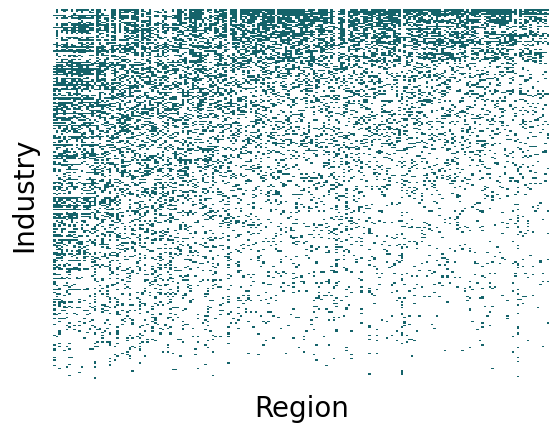

In [6]:
mcl_matrix(rca_df, key_columns=["reg", "ind", "rca01"], heatmap=True, cmap=cmap, size=20)

In [7]:
# KDE plots to illustrate distribution
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

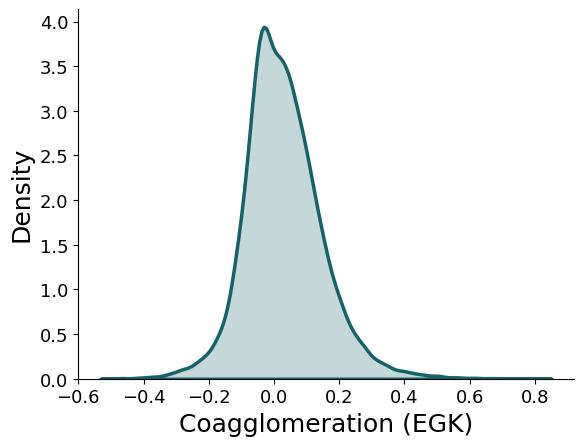

In [8]:
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

#key_var = "egk_coagg"
key_var = "coagg_porter_rca01"

# colormap
cvals  = [reg_df[key_var].min(), reg_df[key_var].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (EGK)",
    fontsize=18
)

In [9]:
reg_df.sort_values(by="egk_coagg", ascending=False)[["ind1", "ind2", "egk_coagg"]].head(10)

,ind1,ind2,egk_coagg
13000,191,241,0.762439
45143,531,652,0.735386
42377,492,531,0.618575
4183,61,262,0.499461
42509,492,652,0.495160
7405,104,531,0.493256
11888,171,191,0.444906
42354,495,504,0.442792
43449,502,643,0.407872
7643,104,652,0.394487


In [11]:
reg_df.sort_values(by="coagg_porter_rca01", ascending=False)[["ind1", "ind2", "coagg_porter_rca01"]].head(10)

,ind1,ind2,coagg_porter_rca01
51447,649,663,0.807429
52314,651,663,0.734002
38119,464,469,0.701437
48076,591,620,0.697470
38623,464,702,0.680567
53331,663,990,0.680381
38127,465,469,0.677296
50035,620,631,0.676393
47541,582,620,0.674817
42728,493,843,0.669802


In [ ]:
# pick 3 different industries in the matrix

# compare them in coagglomeration distribution -- skill relatedness distribution -- IO distribution

In [ ]:
# labor flow example network on the left
# labor flow matrix on the right

In [ ]:
# labor flow example network on the left
# labor flow matrix on the right

**Figure 2 - distance of ties -- v2**

In [6]:
# OC data in
ddf = pd.read_csv("../data/oc15_2023_dec/oc_distance_io_labor_ties.csv", sep=";")
ddf = ddf.fillna(0)

In [4]:
# re-bin distance below 50 km
factors = [10, 25, 50]
for factor in factors:
    ddf[f'dist_int{factor}'] = np.floor(ddf['dist_int'] / factor) * factor

# re-bin distance above 50 km
conditions = [
    (ddf["dist_int"] < 50),
    (ddf["dist_int"] >= 50) & (ddf["dist_int"] < 100),
    (ddf["dist_int"] >= 100) & (ddf["dist_int"] < 200),
    (ddf["dist_int"] >= 200) & (ddf["dist_int"] < 500),
    (ddf["dist_int"] >= 500),
]

choices = [
    ddf["dist_int"],
    ddf["dist_int10"],
    ddf["dist_int25"],
    ddf["dist_int50"],
    np.nan,
]

ddf["dist_combined"] = np.select(conditions, choices, default=np.nan)

In [5]:
# group by dist_combined and calculate aggregated values
agg_cols = ["poss_ties", "obs_io", "obs_labor", "obs_overlap", "nr_io_sr_ties", "io_diff_ind"]
ddf2 = ddf.groupby(["dist_combined"])[agg_cols].sum().reset_index()

# calculate probabilities
prob_cols = ["prob_io", "prob_labor", "prob_overlap"]
ddf2[prob_cols] = ddf2[["obs_io", "obs_labor", "obs_overlap"]].div(ddf2["poss_ties"], axis=0)

# calculate logs
ddf2["log_dist_combined"] = np.log10(ddf2["dist_combined"] + 1)
ddf2[[f"log_{col}" for col in prob_cols]] = ddf2[prob_cols].apply(lambda x: np.log10(x))

# calculate standard errors
ddf2["se_io"] = np.sqrt(ddf2["prob_io"]*(1-ddf2["prob_io"]) / np.sqrt(ddf2["poss_ties"]))
ddf2["se_labor"] = np.sqrt(ddf2["prob_labor"]*(1-ddf2["prob_labor"]) / np.sqrt(ddf2["poss_ties"]))
ddf2["se_overlap"] = np.sqrt(ddf2["prob_overlap"]*(1-ddf2["prob_overlap"]) / np.sqrt(ddf2["poss_ties"]))

# calculate confidence intervals
ddf2["log_prob_labor_conf_up"] = ddf2["log_prob_labor"] - 1.96*(ddf2["se_labor"])
ddf2["log_prob_labor_conf_down"] = ddf2["log_prob_labor"] + 1.96*(ddf2["se_labor"])
ddf2["log_prob_io_conf_up"] = ddf2["log_prob_io"] - 1.96*(ddf2["se_io"])
ddf2["log_prob_io_conf_down"] = ddf2["log_prob_io"] + 1.96*(ddf2["se_io"])
ddf2["log_prob_overlap_conf_up"] = ddf2["log_prob_overlap"] - 1.96*(ddf2["se_overlap"])
ddf2["log_prob_overlap_conf_down"] = ddf2["log_prob_overlap"] + 1.96*(ddf2["se_overlap"])

/opt/homebrew/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
def tie_distance(df, distance_column, var_color_dict, fontsize, yaxis_text, legend_dict, ax=None):
    """function for different x: distance y: ties plots"""
    
    # data preparation
    all_columns = distance_column + list(var_color_dict.keys())
    df = df[all_columns]

    # figure preparation
    if ax is None:
        ax = plt.gca()
    for key, value in var_color_dict.items():
        ax.plot(df[distance_column], df[key], "o-", color=value, markersize=5, linewidth=3, label=legend_dict[key])
        ax.set_xlabel("Distance in km (log)", size=fontsize)
        ax.set_ylabel(yaxis_text, size=fontsize)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

In [7]:
# calculations for SR / no-SR supplier connections
ddf2["nr_io_no_sr_ties"] = ddf2["io_diff_ind"] - ddf2["nr_io_sr_ties"]
ddf2["nr_io_no_sr_ties_total"] = ddf2["nr_io_no_sr_ties"].sum()
ddf2["nr_io_sr_ties_total"] = ddf2["nr_io_sr_ties"].sum()

# shares
ddf2["share_io_no_sr_ties"] = ddf2["nr_io_no_sr_ties"] / ddf2["nr_io_no_sr_ties_total"]
ddf2["share_io_sr_ties"] = ddf2["nr_io_sr_ties"] / ddf2["nr_io_sr_ties_total"]

# confidence intervals
ddf2["se_io_no_sr"] = np.sqrt(ddf2["share_io_no_sr_ties"]*(1-ddf2["share_io_no_sr_ties"])) / np.sqrt(ddf2["nr_io_sr_ties_total"])
ddf2["share_io_no_sr_ties_ci"] = 1.96*(ddf2["se_io_no_sr"])
#ddf2["share_io_no_sr_ties_ci"] = ddf2["share_io_no_sr_ties"] - 1.96*(ddf2["se_io_no_sr"])
#ddf2["share_io_no_sr_ties_L"] = ddf2["share_io_no_sr_ties"] + 1.96*(ddf2["se_io_no_sr"])

ddf2["se_io_sr"] = np.sqrt(ddf2["share_io_sr_ties"]*(1-ddf2["share_io_sr_ties"])) / np.sqrt(ddf2["nr_io_sr_ties_total"])
ddf2["share_io_sr_ties_ci"] = 1.96*(ddf2["se_io_sr"])
#ddf2["share_io_no_sr_ties_L"] = ddf2["share_io_no_sr_ties"] + 1.96*(ddf2["se_for_plot"])


/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_87052/2789239785.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_87052/2789239785.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_yticklabels(["", "", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_87052/2789239785.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  limited_df["dist_combined"] = limited_df["dist_combined"].astype(int)


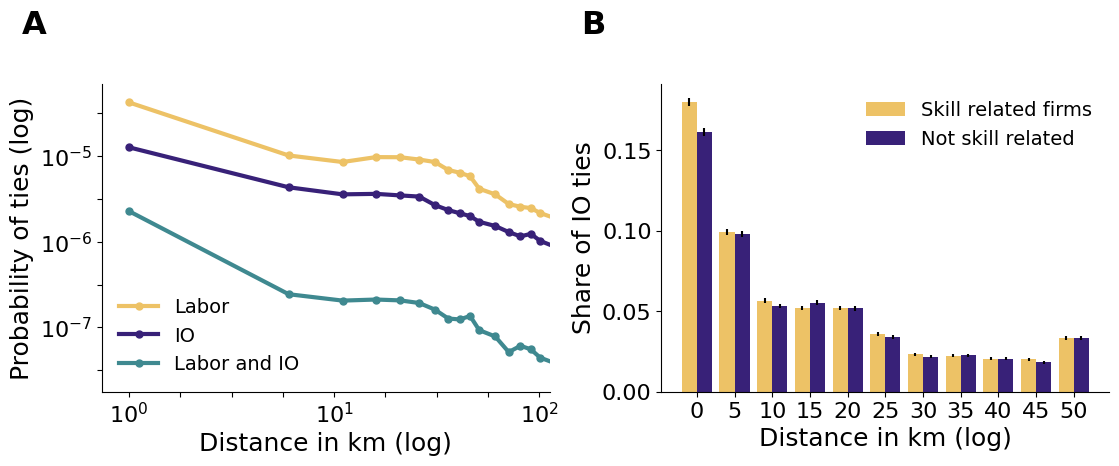

In [14]:
# distance decay figure
fig, ax = plt.subplots(1,2, figsize=(13,4))
plt.subplots_adjust(wspace=0.25)
fontsize=18


# A -- probability of ties
color_dict = {"log_prob_labor":"#EDC266", "log_prob_io":"#382178", "log_prob_overlap":"#3F8990"}
legend_text = {"log_prob_labor":"Labor", "log_prob_io":"IO", "log_prob_overlap":"Labor and IO"}
tie_distance(
    ddf2,
    distance_column=["log_dist_combined"],
    var_color_dict=color_dict,
    fontsize=fontsize,
    yaxis_text="Probability of ties (log)",
    legend_dict=legend_text,
    ax=ax[0]
)
ax[0].set_xlim(-0.13270882709389803, 2.05)
ax[0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)
#print(ax[0].get_xlim())
ax[0].set_ylim(-7.75, -4.15)
ax[0].set_yticklabels(["", "", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$", ""], size=fontsize-2)
ax[0].legend(loc="lower left", prop={'size': fontsize-4}, frameon=False)


# B -- barplot version
limited_df = ddf2[ddf2["dist_combined"] <= 50]
limited_df["dist_combined"] = limited_df["dist_combined"].astype(int)

bar_width = 0.40
index = np.arange(len(limited_df["dist_combined"]))

ax[1].bar(
        index,
        limited_df["share_io_sr_ties"],
        bar_width,
        label="Skill related firms",
        yerr=[limited_df["share_io_sr_ties_ci"], limited_df["share_io_sr_ties_ci"]],
        capsize=0,
        color="#EDC266"
)

ax[1].bar(
        index + bar_width,
        limited_df["share_io_no_sr_ties"],
        bar_width,
        label="Not skill related",
        yerr=[limited_df["share_io_no_sr_ties_ci"], limited_df["share_io_no_sr_ties_ci"]],
        capsize=0,
        color="#382178"
)
ax[1].set_xticks(index + bar_width / 2, limited_df["dist_combined"], size=fontsize-2)
ax[1].set_xlabel("Distance in km (log)", size=fontsize)
ax[1].set_ylabel("Share of IO ties", size=fontsize)
ax[1].tick_params("y", labelsize=(fontsize-2))
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].legend(loc="upper right", prop={'size': fontsize-4}, frameon=False)


# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=fontsize+5)

# plt.savefig(f"../figures/mf03_gravity_share_sr.png", dpi=300, bbox_inches='tight', facecolor="white")

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_81798/896309707.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_xticklabels(["", "$10^0$", "", "$10^1$", "", "$10^2$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_81798/896309707.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_yticklabels(["", "$10^{-8}$", "$10^{-7}$", "$10^{-6}$", "$10^{-5}$"], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_81798/896309707.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].set_xticklabels(["", "$10^0$", "", "$10^1$", "", "$10^2$", ""], size=fontsize-2)


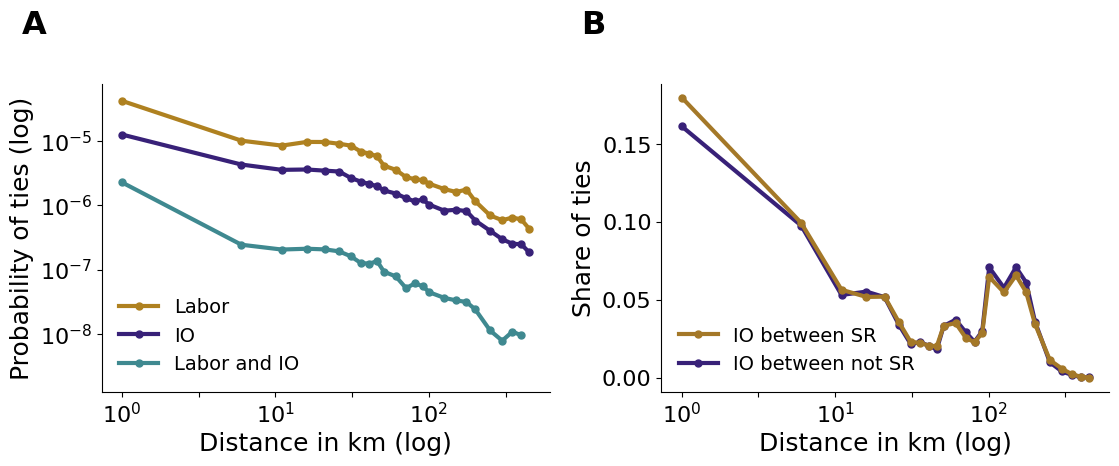

In [8]:
# distance decay figure
fig, ax = plt.subplots(1,2, figsize=(13,4))
plt.subplots_adjust(wspace=0.25)
fontsize=18
add_conf_int = False

# A -- probability of ties
color_dict = {"log_prob_labor":"#AF8120", "log_prob_io":"#382178", "log_prob_overlap":"#3F8990"}
legend_text = {"log_prob_labor":"Labor", "log_prob_io":"IO", "log_prob_overlap":"Labor and IO"}
tie_distance(
    ddf2,
    distance_column=["log_dist_combined"],
    var_color_dict=color_dict,
    fontsize=fontsize,
    yaxis_text="Probability of ties (log)",
    legend_dict=legend_text,
    ax=ax[0]
)
ax[0].set_xticklabels(["", "$10^0$", "", "$10^1$", "", "$10^2$", ""], size=fontsize-2)
#ax[0].set_xlim(-0.13270882709389803, 1.55)
#print(ax[0].get_xlim())
ax[0].set_ylim(-8.9, -4.1)
ax[0].set_yticklabels(["", "$10^{-8}$", "$10^{-7}$", "$10^{-6}$", "$10^{-5}$"], size=fontsize-2)
ax[0].legend(loc="lower left", prop={'size': fontsize-4}, frameon=False)

if add_conf_int==True:
    ax[0].fill_between(ddf2["log_dist_combined"], ddf2["log_prob_labor_conf_up"], ddf2["log_prob_labor_conf_down"], color='b', alpha=.1)


# B -- share of IO ties -- SR / NO SR
ax[1].plot(ddf2["log_dist_combined"], ddf2["share_io_sr_ties"], "o-", color="#A47828", markersize=5, linewidth=3, label="IO between SR")
ax[1].plot(ddf2["log_dist_combined"], ddf2["share_io_no_sr_ties"], "o-", color="#382178", markersize=5, linewidth=3, label="IO between not SR", zorder=1)
ax[1].set_xlabel("Distance in km (log)", size=fontsize)
ax[1].set_ylabel("Share of ties", size=fontsize)
ax[1].tick_params("y", labelsize=(fontsize-2))
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].set_xticklabels(["", "$10^0$", "", "$10^1$", "", "$10^2$", ""], size=fontsize-2)
ax[1].legend(loc="lower left", prop={'size': fontsize-4}, frameon=False)

if add_conf_int==True:
    ax[1].fill_between(ddf2["log_dist_combined"], ddf2["share_io_no_sr_ties_U"], ddf2["share_io_no_sr_ties_L"], color='b', alpha=.1)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=fontsize+5)

# plt.savefig(f"../figures/mf03_gravity_of_ties.png", dpi=300, bbox_inches='tight', facecolor="white")

**distance of ties by industry**

In [197]:
# distance of ties by industry
id_table = pd.read_csv("../data/oc17_2024_febr2/ind_dist_table_nace2d_2017.csv", sep=";")

In [198]:
id_table.head(2)

,ind1,nr_firms,avg_dist_io_all,sd_dist_io_all,nr_ties_io_all,avg_dist_lab_all,sd_dist_lab_all,nr_ties_lab_all,avg_dist_io_diffind,sd_dist_io_diffind,nr_ties_io_diffind,avg_dist_lab_diffind,sd_dist_lab_diffind,nr_ties_lab_diffind,avg_dist_io_sr,sd_dist_io_sr,nr_ties_io_sr,avg_dist_io_not_sr,sd_dist_io_not_sr,nr_ties_io_not_sr
0,1,17736,80.212,79.022,20347.0,62.113,71.902,29395.0,94.073,80.617,13991.0,94.073,80.617,13991.0,93.312,81.625,10597.0,96.450,77.349,3394.0
1,2,2328,68.943,69.239,2171.0,60.560,64.491,4067.0,75.422,74.165,1545.0,75.422,74.165,1545.0,69.432,75.186,907.0,83.937,71.892,638.0


In [313]:
# manipulation
id_table["sr_dist_diff"] = id_table["avg_dist_io_sr"] - id_table["avg_dist_io_not_sr"]
id_table = id_table[id_table["nr_firms"]>=100]
id_table.sort_values(by="ind1", ascending=False, inplace=True)

sr_io = id_table[id_table["sr_dist_diff"] <= 0]
sr_not_io = id_table[id_table["sr_dist_diff"] > 0]

In [316]:
sr_io

,ind1,nr_firms,avg_dist_io_all,sd_dist_io_all,nr_ties_io_all,avg_dist_lab_all,sd_dist_lab_all,nr_ties_lab_all,avg_dist_io_diffind,sd_dist_io_diffind,...,sd_dist_lab_diffind,nr_ties_lab_diffind,avg_dist_io_sr,sd_dist_io_sr,nr_ties_io_sr,avg_dist_io_not_sr,sd_dist_io_not_sr,nr_ties_io_not_sr,sr_dist_diff,sr_dist_ratio
84,96,10284,57.219,67.314,688.0,50.107,64.746,8866.0,57.488,66.906,...,66.906,654.0,51.180,65.031,250.0,61.391,67.826,404.0,-10.211,0.833673
83,95,2819,43.901,62.371,790.0,45.123,65.864,1411.0,43.202,62.033,...,62.033,762.0,36.556,57.293,392.0,50.243,66.039,370.0,-13.687,0.727584
81,93,4387,58.699,71.258,2593.0,55.713,68.793,7473.0,54.084,68.781,...,68.781,2167.0,46.136,64.180,905.0,59.784,71.381,1262.0,-13.648,0.771711
80,92,737,71.833,76.747,72.0,45.248,68.816,1135.0,69.735,75.096,...,75.096,68.0,61.161,76.597,31.0,76.919,74.094,37.0,-15.758,0.795135
79,91,954,57.434,69.776,511.0,86.313,83.738,425.0,51.641,67.153,...,67.153,449.0,47.188,65.847,181.0,54.649,67.977,268.0,-7.461,0.863474
78,90,2165,43.206,62.939,1655.0,40.969,58.179,2549.0,40.579,60.171,...,60.171,1277.0,35.293,56.356,676.0,46.526,63.716,601.0,-11.233,0.758565
76,87,1175,49.839,83.461,31.0,62.451,67.306,51.0,48.793,86.289,...,86.289,29.0,31.667,37.448,3.0,50.769,90.487,26.0,-19.102,0.623747
74,85,15471,56.655,71.607,1352.0,83.269,81.714,14012.0,57.571,71.758,...,71.758,1298.0,49.460,67.216,658.0,65.909,75.292,640.0,-16.449,0.750429
72,82,7349,45.603,64.056,4258.0,55.175,66.027,22237.0,46.511,64.238,...,64.238,3908.0,36.026,56.999,1829.0,55.734,68.694,2079.0,-19.708,0.646392
71,81,6538,56.790,71.055,4106.0,62.063,71.021,30687.0,58.652,70.627,...,70.627,3352.0,55.495,69.537,1326.0,60.718,71.273,2026.0,-5.223,0.913979


(-2.0, 100.0)

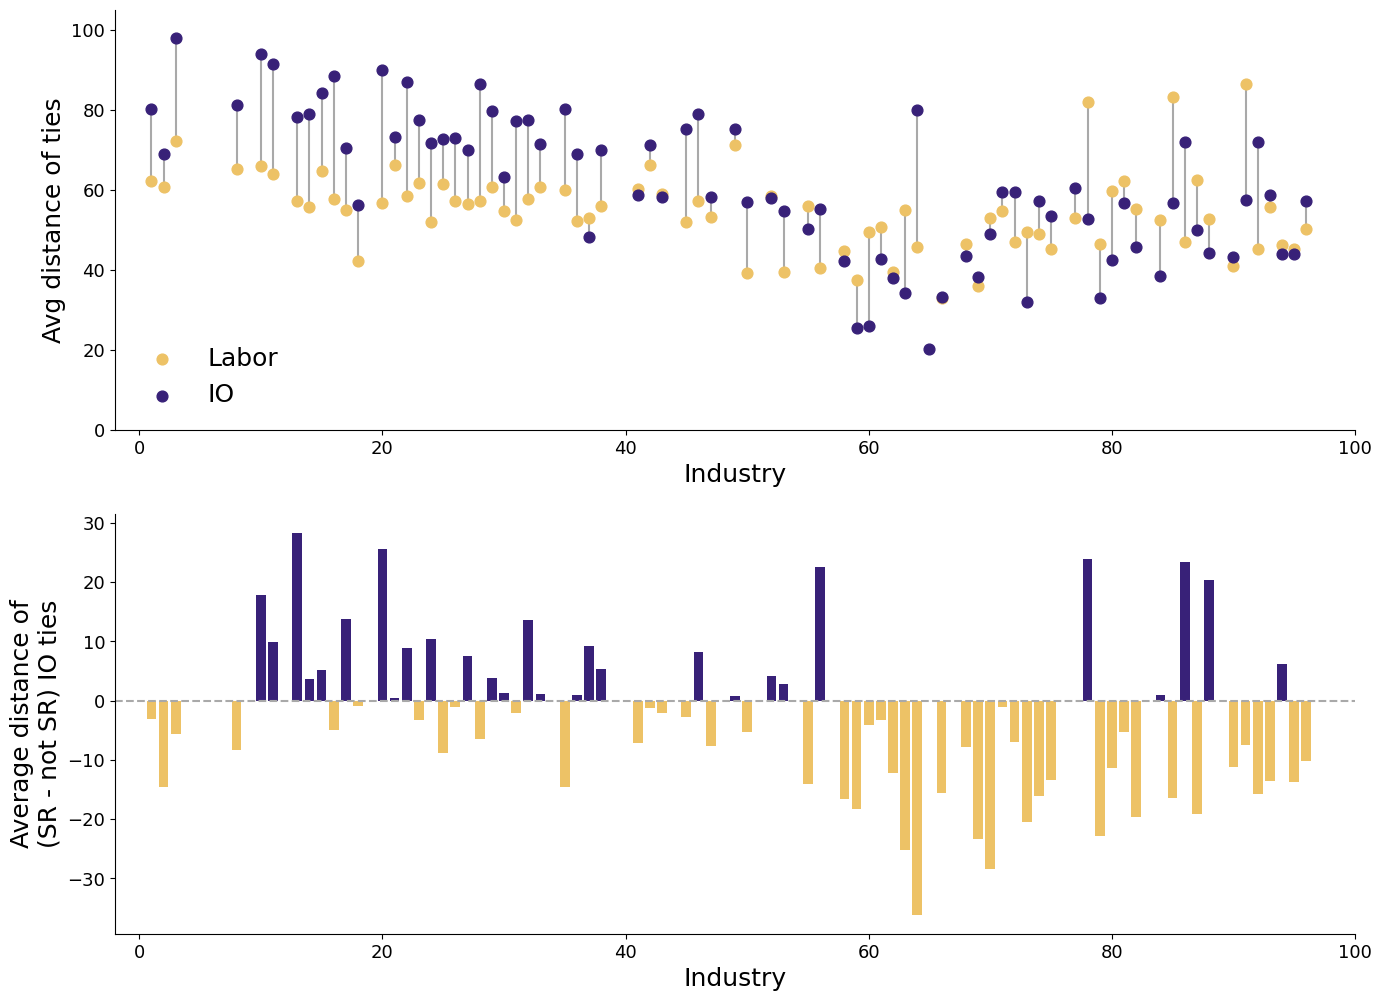

In [321]:
fig, ax = plt.subplots(2,1, figsize=(16,12))
fontsize=18
bar_width = 0.40
index = np.arange(len(id_table["ind1"]))

ax[0].scatter(id_table["ind1"], id_table["avg_dist_lab_all"], label="Labor", color="#EDC266", zorder=2, s=60)
ax[0].scatter(id_table["ind1"], id_table["avg_dist_io_all"], label="IO", color="#382178", zorder=2, s=60)
ax[0].vlines(id_table["ind1"], ymin=id_table["avg_dist_lab_all"], ymax=id_table["avg_dist_io_all"], color="darkgrey", zorder=1)
ax[0].set_xlabel("Industry", size=fontsize)
ax[0].set_ylabel("Avg distance of ties", size=fontsize)
ax[0].tick_params("x", labelsize=(fontsize-5))
ax[0].tick_params("y", labelsize=(fontsize-5))
ax[0].margins(0.015, tight=True)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_ylim(0, 105)
ax[0].set_xlim(-2, 100)
ax[0].legend(loc="lower left", prop={'size': fontsize}, frameon=False)

ax[1].bar(sr_io["ind1"], sr_io["sr_dist_diff"], color="#EDC266")
ax[1].bar(sr_not_io["ind1"], sr_not_io["sr_dist_diff"], color="#382178")
ax[1].axhline(y=0, color="darkgrey", linestyle="--")
ax[1].set_xlabel("Industry", size=fontsize)
ax[1].set_ylabel("Average distance of\n(SR - not SR) IO ties", size=fontsize)
ax[1].tick_params("x", labelsize=(fontsize-5))
ax[1].tick_params("y", labelsize=(fontsize-5))
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].set_xlim(-2, 100)

(0.0, 105.0)

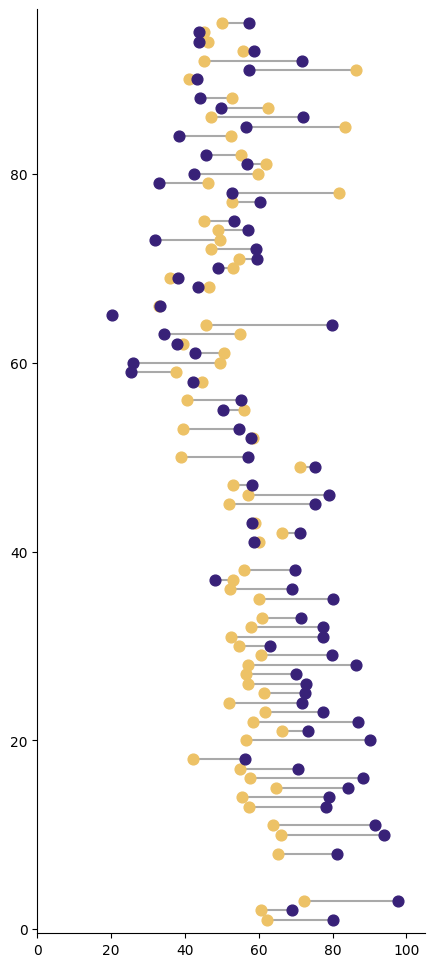

In [269]:
fig, ax = plt.subplots(1,1, figsize=(5,12))
fontsize=18
bar_width = 0.40
#index = np.arange(len(id_table["ind1"]))

ax.scatter(id_table["avg_dist_lab_all"], id_table["ind1"], label="Labor flow", color="#EDC266", zorder=2, s=60)
ax.scatter(id_table["avg_dist_io_all"], id_table["ind1"], label="Labor flow", color="#382178", zorder=2, s=60)
ax.hlines(y=id_table["ind1"], xmin=id_table["avg_dist_lab_all"], xmax=id_table["avg_dist_io_all"], color="darkgrey", zorder=1)
#ax.set_xlabel("Industry", size=fontsize)
#ax.set_ylabel("Avg distance of ties", size=fontsize)
ax.margins(0.015, tight=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 105)

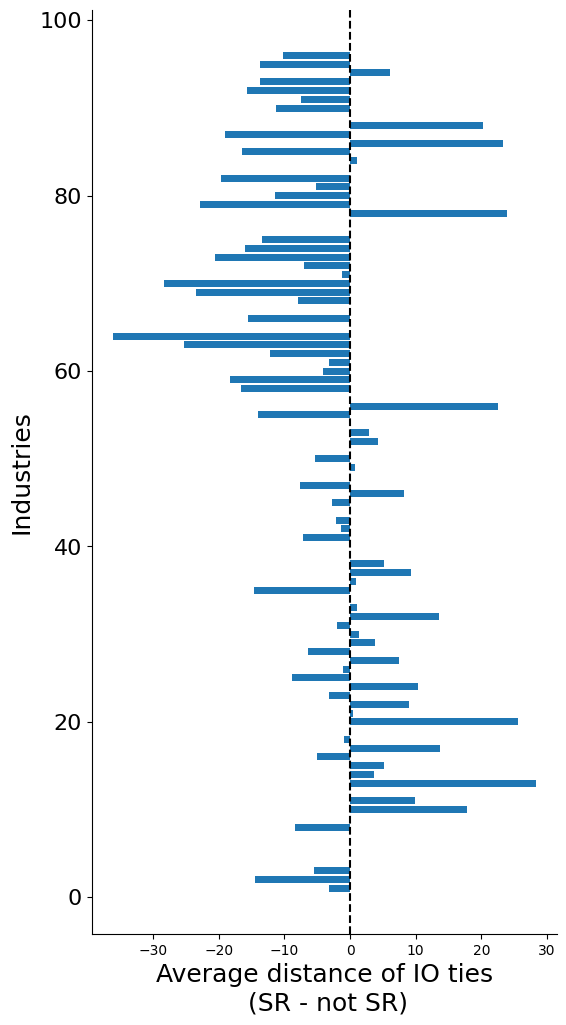

In [205]:
fig, ax = plt.subplots(1,1, figsize=(6,12))
fontsize=18
ax.barh(id_table["ind1"], id_table["sr_dist_diff"])
ax.axvline(x=0, color="black", linestyle="--")
ax.set_xlabel("Average distance of IO ties\n (SR - not SR)", size=fontsize)
ax.set_ylabel("Industries", size=fontsize)
ax.tick_params("y", labelsize=(fontsize-2))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


Text(0, 0.5, 'Distance difference of IO \nSR vs not SR ')

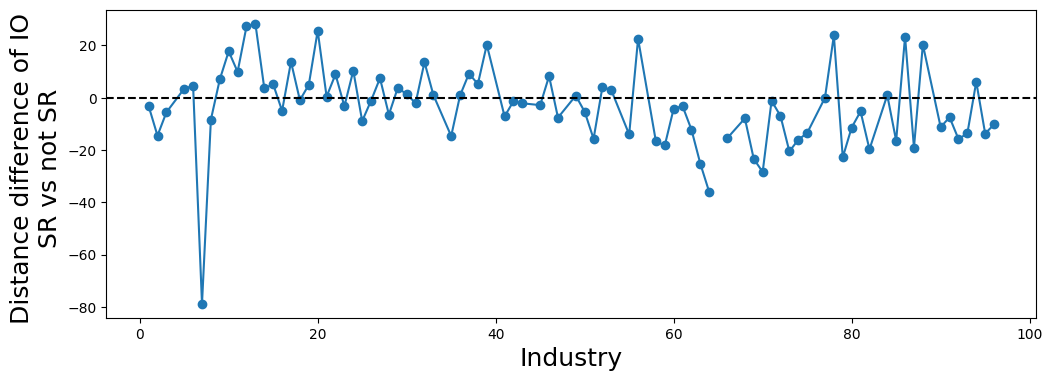

In [40]:
fig, ax = plt.subplots(1,1, figsize=(12,4))
fontsize=18
ax.plot(id_table["ind1"], id_table["sr_dist_diff"], "o-")
ax.axhline(y=0, color="black", linestyle="--")
ax.set_xlabel("Industry", size=fontsize)
ax.set_ylabel("Distance difference of IO \nSR vs not SR ", size=fontsize)

In [43]:
id_table[id_table["sr_dist_diff"] < -20]

,ind1,nr_firms,avg_dist_io_all,sd_dist_io_all,nr_ties_io_all,avg_dist_lab_all,sd_dist_lab_all,nr_ties_lab_all,avg_dist_io_diffind,sd_dist_io_diffind,...,avg_dist_lab_diffind,sd_dist_lab_diffind,nr_ties_lab_diffind,avg_dist_io_sr,sd_dist_io_sr,nr_ties_io_sr,avg_dist_io_not_sr,sd_dist_io_not_sr,nr_ties_io_not_sr,sr_dist_diff
5,7,6,72.692,57.966,13.0,55.400,65.612,25.0,72.692,57.966,...,72.692,57.966,13.0,0.000,NaN,1.0,78.750,56.081,12.0,-78.750
55,63,2206,34.269,56.218,1191.0,54.920,70.525,3439.0,35.022,56.849,...,35.022,56.849,1137.0,24.023,45.097,642.0,49.287,66.572,495.0,-25.264
56,64,1091,79.830,70.918,6842.0,45.724,60.271,156.0,80.207,70.903,...,80.207,70.903,6804.0,46.229,65.933,402.0,82.341,70.666,6402.0,-36.112
60,69,14777,38.068,59.021,3123.0,35.995,57.055,8835.0,39.953,59.475,...,39.953,59.475,2769.0,30.811,53.863,1687.0,54.207,64.797,1082.0,-23.396
61,70,8674,49.019,65.727,8501.0,52.892,69.152,14389.0,50.998,66.938,...,50.998,66.938,7643.0,41.777,62.002,5159.0,70.147,72.534,2484.0,-28.370
64,73,3855,32.005,51.882,4982.0,49.474,65.915,6876.0,36.282,55.173,...,36.282,55.173,3918.0,30.174,51.519,2751.0,50.679,60.588,1167.0,-20.505
69,79,1376,32.858,56.463,625.0,46.318,65.801,2354.0,34.969,57.955,...,34.969,57.955,557.0,29.487,53.758,423.0,52.276,66.889,134.0,-22.789


In [173]:
# ind-ind
idid_table = pd.read_csv("../data/oc17_2024_febr2/indind_dist_nace2d_2017.csv", sep=";")

In [151]:
idid_table.head(2)

,ind1,ind2,nr_firms1,nr_firms2,avg_dist_io,sd_dist_io,nr_ties_io,avg_dist_lab,sd_dist_lab,nr_ties_lab,avg_dist_io_sr,sd_dist_io_sr,nr_ties_io_sr,avg_dist_io_not_sr,sd_dist_io_not_sr,nr_ties_io_not_sr
0,1,2,17736,2328,35.917,53.779,48.0,45.171,63.712,181.0,35.917,53.779,48.0,NaN,NaN,NaN
1,1,3,17736,212,32.600,38.848,10.0,79.388,67.699,49.0,32.600,38.848,10.0,NaN,NaN,NaN


In [174]:
idid_table["avg_dist_io_sr"] = np.where(idid_table["avg_dist_io_sr"] <=25, 25, idid_table["avg_dist_io_sr"])
idid_table["avg_dist_io_sr"] = np.where((idid_table["avg_dist_io_sr"] >10) & (idid_table["avg_dist_io_sr"] <=50), 50, idid_table["avg_dist_io_sr"])
idid_table["avg_dist_io_sr"] = np.where((idid_table["avg_dist_io_sr"] >50) & (idid_table["avg_dist_io_sr"] <=100), 100, idid_table["avg_dist_io_sr"])
idid_table["avg_dist_io_sr"] = np.where((idid_table["avg_dist_io_sr"] >100) & (idid_table["avg_dist_io_sr"] <=200), 200, idid_table["avg_dist_io_sr"])
idid_table["avg_dist_io_sr"] = np.where(idid_table["avg_dist_io_sr"] >200, 300, idid_table["avg_dist_io_sr"])

idid_table["avg_dist_io_not_sr"] = np.where(idid_table["avg_dist_io_not_sr"] <=25, 25, idid_table["avg_dist_io_not_sr"])
idid_table["avg_dist_io_not_sr"] = np.where((idid_table["avg_dist_io_not_sr"] >10) & (idid_table["avg_dist_io_not_sr"] <=50), 50, idid_table["avg_dist_io_not_sr"])
idid_table["avg_dist_io_not_sr"] = np.where((idid_table["avg_dist_io_not_sr"] >50) & (idid_table["avg_dist_io_not_sr"] <=100), 100, idid_table["avg_dist_io_not_sr"])
idid_table["avg_dist_io_not_sr"] = np.where((idid_table["avg_dist_io_not_sr"] >100) & (idid_table["avg_dist_io_not_sr"] <=200), 200, idid_table["avg_dist_io_not_sr"])
idid_table["avg_dist_io_not_sr"] = np.where(idid_table["avg_dist_io_not_sr"] >200, 300, idid_table["avg_dist_io_not_sr"])

In [175]:
idid_table

,ind1,ind2,nr_firms1,nr_firms2,avg_dist_io,sd_dist_io,nr_ties_io,avg_dist_lab,sd_dist_lab,nr_ties_lab,avg_dist_io_sr,sd_dist_io_sr,nr_ties_io_sr,avg_dist_io_not_sr,sd_dist_io_not_sr,nr_ties_io_not_sr
0,1,2,17736,2328,35.917,53.779,48.0,45.171,63.712,181.0,50.0,53.779,48.0,NaN,NaN,NaN
1,1,3,17736,212,32.600,38.848,10.0,79.388,67.699,49.0,50.0,38.848,10.0,NaN,NaN,NaN
2,1,5,17736,22,117.000,NaN,1.0,45.000,NaN,1.0,200.0,NaN,1.0,NaN,NaN,NaN
3,1,6,17736,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,7,17736,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3736,95,97,2819,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3737,95,99,2819,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3738,96,97,10284,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3739,96,99,10284,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [176]:
def indind_matrix(df, key_columns, take_log, heatmap, size, ax=None):    
    table = pd.pivot_table(
        df,
        index=key_columns[0],
        columns=key_columns[1],
        values=key_columns[2],
        aggfunc=np.mean
    )
    
    if take_log==True:
        table = np.log10(table)

    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cmap="Blues_r", ax=ax)
        #ax.set_title("Number of POIs", size=size)
        ax.set_xlabel("Industry", size=size)
        ax.set_ylabel("Industry", size=size)
        #ax.set_xticklabels("")
        ax.tick_params("y", labelsize=size-9)
        ax.tick_params(left = False, bottom = False)

In [177]:
idid_table.avg_dist_io_sr.value_counts()


50.0     339
100.0    318
200.0     88
300.0      2
Name: avg_dist_io_sr, dtype: int64

In [178]:
idid_table.avg_dist_io_not_sr.value_counts()

100.0    700
50.0     641
200.0    255
300.0     18
Name: avg_dist_io_not_sr, dtype: int64

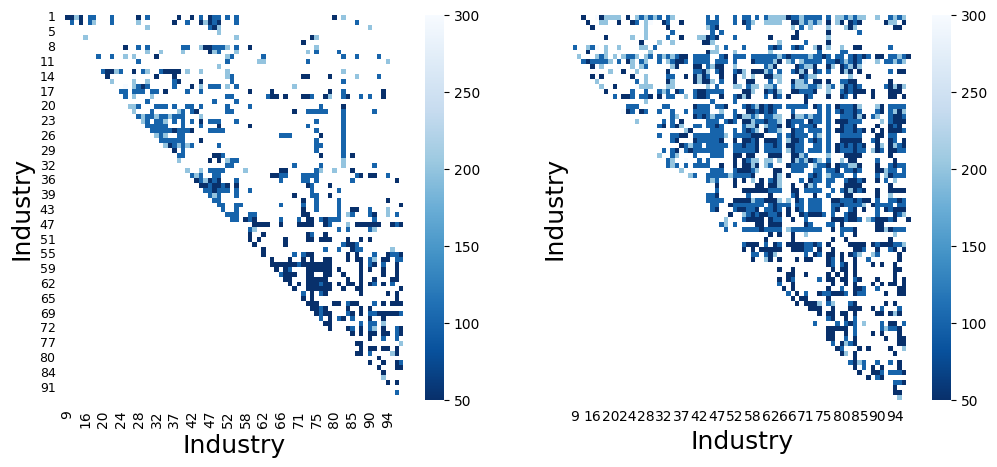

In [179]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharex=True, sharey=True)
fontsize=18

indind_matrix(idid_table, key_columns=["ind1", "ind2", "avg_dist_io_sr"], take_log=False, heatmap=True, size=fontsize, ax=ax[0])
indind_matrix(idid_table, key_columns=["ind1", "ind2", "avg_dist_io_not_sr"], take_log=False, heatmap=True, size=fontsize, ax=ax[1])

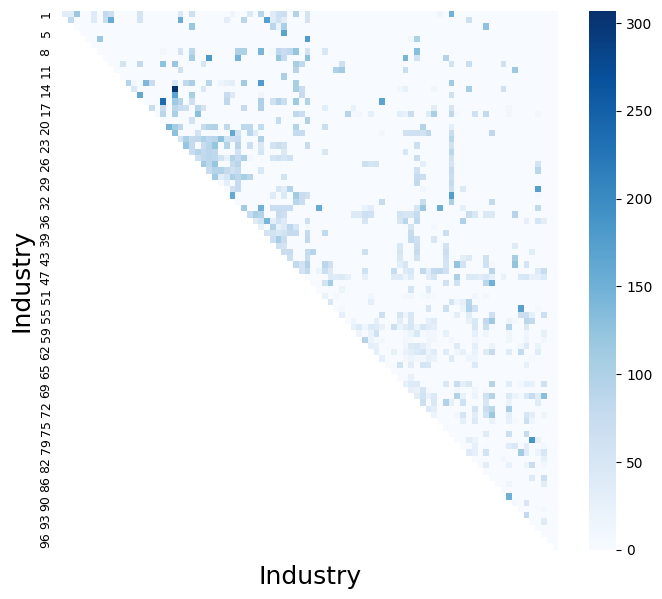

In [58]:

size=18
fig, ax = plt.subplots(1,1, figsize=(8,7))

pivot_table = idid_table.pivot_table(index="ind1", columns="ind2", values="avg_dist_io_sr", aggfunc="sum")
log_pivot_table = np.log10(pivot_table)

sns.heatmap(pivot_table, cbar=True, cmap="Blues", ax=ax)
#ax.set_title("Number of POIs", size=size)
ax.set_xlabel("Industry", size=size)
ax.set_ylabel("Industry", size=size)
ax.set_xticklabels("")
ax.tick_params("y", labelsize=9)
ax.tick_params(left = False, bottom = False)

<BarContainer object of 87 artists>

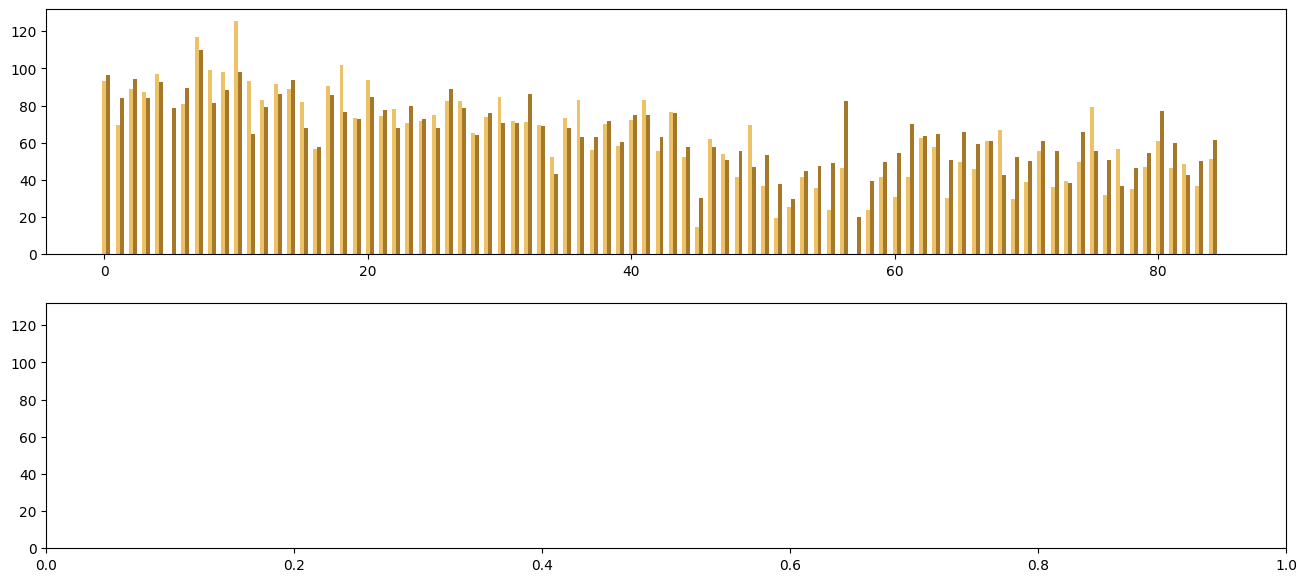

In [15]:
fig, ax = plt.subplots(2,1, figsize=(16,7), sharey=True)
fontsize=18


bar_width = 0.3
index = np.arange(len(test["ind1"]))

ax[0].bar(
        index,
        test["avg_dist_io_sr"],
        bar_width,
        label="Skill related firms",
        #yerr=[limited_df["share_io_sr_ties_ci"], limited_df["share_io_sr_ties_ci"]],
        #capsize=0,
        color="#EDC266"
)
ax[0].bar(
        index + bar_width,
        test["avg_dist_io_not_sr"],
        bar_width,
        label="Skill related firms",
        #yerr=[limited_df["share_io_sr_ties_ci"], limited_df["share_io_sr_ties_ci"]],
        #capsize=0,
        color="#A47828"
)


#ax[0].bar(test["ind1"], test["avg_dist_io_sr"], color="#3F8990")
#ax[1].bar(test["ind1"], test["avg_dist_io_not_sr"], color="#3F8990")

In [9]:
fig, ax = plt.subplots(1,1, figsize=(12,7))
fontsize=18


ax.bar(test["nace2d"], test["total_emp"], color="#3F8990")

ax[0].set_ylabel("Employment (log)", size=fontsize)
ax[0].tick_params("x", labelsize=(fontsize-2))
ax[0].tick_params("y", labelsize=(fontsize-2))
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].margins(0.015, tight=True)


# firms
ax[1].bar(ind_df["nace2d"], ind_df["total_firms"], color="#3F8990")
ax[1].semilogy()
ax[1].set_xlabel("Industries", size=fontsize)
ax[1].set_ylabel("Nr. firms (log)", size=fontsize)
ax[1].tick_params("x", labelsize=(fontsize-2))
ax[1].tick_params("y", labelsize=(fontsize-2))
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].margins(0.015, tight=True)

# subplot title
ax[0].annotate("A", xy=(-0.115,0.95), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)
ax[0].annotate("B", xy=(-0.115,-0.25), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)

# plt.savefig(f"../figures/si_industries_emp_firms.png", dpi=300, bbox_inches='tight', facecolor="white")

,ind1,nr_firms,avg_dist_io_all,sd_dist_io_all,nr_ties_io_all,avg_dist_lab_all,sd_dist_lab_all,nr_ties_lab_all,avg_dist_io_diffind,sd_dist_io_diffind,nr_ties_io_diffind,avg_dist_lab_diffind,sd_dist_lab_diffind,nr_ties_lab_diffind,avg_dist_io_sr,sd_dist_io_sr,nr_ties_io_sr,avg_dist_io_not_sr,sd_dist_io_not_sr,nr_ties_io_not_sr
0,1,17736,80.212,79.022,20347.0,62.113,71.902,29395.0,94.073,80.617,13991.0,94.073,80.617,13991.0,93.312,81.625,10597.0,96.450,77.349,3394.0
1,2,2328,68.943,69.239,2171.0,60.560,64.491,4067.0,75.422,74.165,1545.0,75.422,74.165,1545.0,69.432,75.186,907.0,83.937,71.892,638.0
2,3,212,97.825,70.672,354.0,72.192,70.177,832.0,91.875,70.680,208.0,91.875,70.680,208.0,88.670,74.065,88.0,94.225,68.311,120.0
3,5,22,79.469,63.703,32.0,56.808,62.006,26.0,84.767,62.236,30.0,84.767,62.236,30.0,87.429,47.088,7.0,83.957,67.068,23.0
4,6,7,91.328,79.340,61.0,42.409,47.539,22.0,94.424,78.832,59.0,94.424,78.832,59.0,97.125,74.101,24.0,92.571,82.934,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,94,3397,43.877,65.296,739.0,46.263,63.152,175.0,44.186,65.307,705.0,44.186,65.307,705.0,48.498,70.029,209.0,42.369,63.197,496.0
83,95,2819,43.901,62.371,790.0,45.123,65.864,1411.0,43.202,62.033,762.0,43.202,62.033,762.0,36.556,57.293,392.0,50.243,66.039,370.0
84,96,10284,57.219,67.314,688.0,50.107,64.746,8866.0,57.488,66.906,654.0,57.488,66.906,654.0,51.180,65.031,250.0,61.391,67.826,404.0
85,97,18,0.000,0.000,2.0,NaN,NaN,NaN,0.000,0.000,2.0,0.000,0.000,2.0,NaN,NaN,NaN,0.000,0.000,2.0


**distance of ties industry-industry**

**Figure x - coagglomeration, IO connections, labor flow**

In [26]:
# load data
df3 = pd.read_csv(f"../data/oc10_2023_sep/oc_mdf3_{region_level}_{year}_based.csv", sep=";")

In [33]:
def z_score(values):
    new_values = (values - np.mean(values)) / (np.max(values) - np.min(values))
    return new_values

In [36]:
# variables manipulation
df3["coagg_stand"] = z_score(df3["egk_coagg"])
df3["io_stand"] = z_score(df3["io_norm"])
df3["lab_stand"] = z_score(df3["sr_norm"])

# clear setting
columns_to_consider = ["coagg_porter", "coagg_porter_mne", "coagg_porter_local", "io_stand", "lab_stand"]
df3 = df3.dropna(subset=columns_to_consider)

In [38]:
def matrix_represantation(df, key_columns, sort_matrix, heatmap, fontsize, title_text, cmap, ax=None):
    """matrix or pivot table representation of our key variables"""
    table = df[key_columns]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_columns]
    table = pd.concat([table, table2])

    # pivot transformation
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[0],
        columns=key_columns[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    # option to sort the matrix
    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
    
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    # option to keep the table or create heatmap
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_title(title_text, size=fontsize)
        ax.yaxis.set_tick_params(rotation=0, labelbottom=True)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

In [41]:
# matrix_represantation(df3, key_columns=["ind1", "ind2", "coagg_stand"], sort_matrix=False, heatmap=True, fontsize=25, title_text="EGK coagglomeration", cmap="Blues")

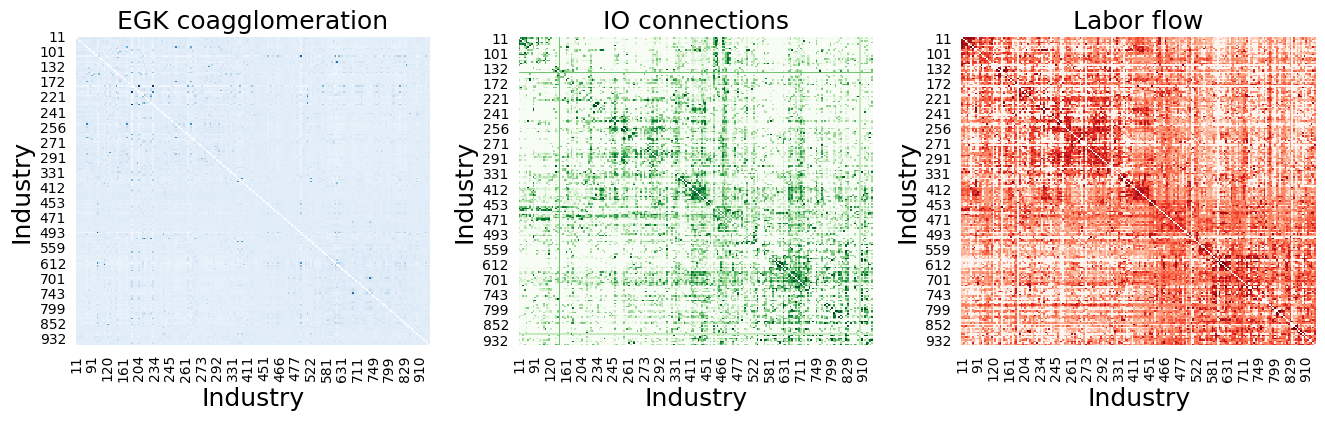

In [42]:
fig, ax = plt.subplots(1,3, figsize=(16,4), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.25)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "coagg_stand"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="EGK coagglomeration",
    cmap="Blues",
    ax=ax[0]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "io_stand"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="IO connections",
    cmap="Greens",
    ax=ax[1]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "lab_stand"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="Labor flow",
    cmap="Reds",
    ax=ax[2]
)

In [43]:
# add kde plots below the matrix row
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [69]:
# density_plot(df3, key_column="coagg_stand", colorway = "#2C728EFF", xlabel_text="EGK coagglomeration", fontsize=15)

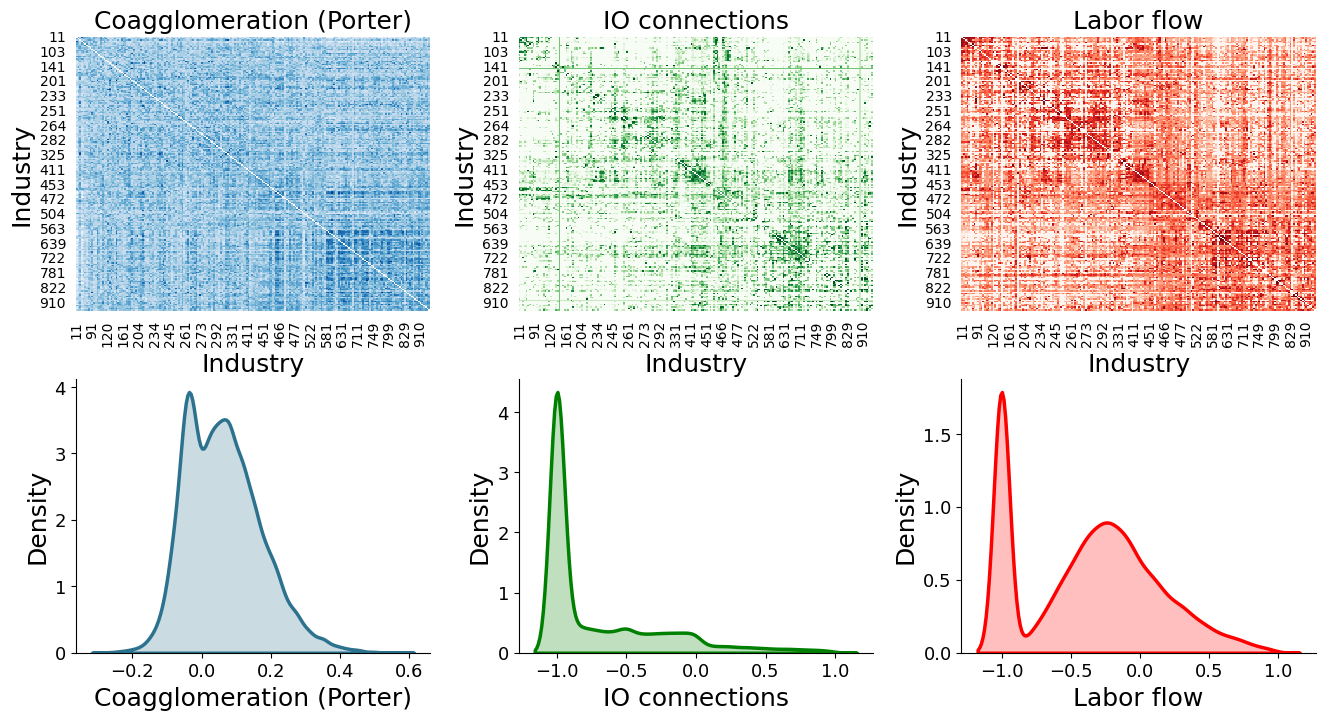

In [52]:
fig, ax = plt.subplots(2,3, figsize=(16,8))
plt.subplots_adjust(wspace=0.25, hspace=0.25)

matrix_represantation(
    df3,
    #key_columns=["ind1", "ind2", "egk_coagg"],
    key_columns=["ind1", "ind2", "coagg_porter"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="Coagglomeration (Porter)",
    cmap="Blues",
    ax=ax[0,0]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "io_norm"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="IO connections",
    cmap="Greens",
    ax=ax[0,1]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "sr_norm"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="Labor flow",
    cmap="Reds",
    ax=ax[0,2]
)

density_plot(
    df3,
    #key_column="egk_coagg",
    key_column="coagg_porter",
    colorway="#2C728EFF",
    xlabel_text="Coagglomeration (Porter)",
    fontsize=18,
    ax=ax[1,0]
)

density_plot(
    df3,
    key_column="io_norm",
    colorway="Green",
    xlabel_text="IO connections",
    fontsize=18,
    ax=ax[1,1]
)

density_plot(
    df3,
    key_column="sr_norm",
    colorway="Red",
    xlabel_text="Labor flow",
    fontsize=18,
    ax=ax[1,2]
)
